In [1]:
# performing naive bayes on the cleaned_dataset_no_outliers.csv

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


In [ ]:
df = pd.read_csv('cleaned_dataset_ARM.csv')
df.head()

,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms,Orbit_Category,Size_Category
0,2000254,254 Augusta,0,0,11.7,12.467000,0.170000,0.137000,JPL 32,2459000.5,...,0.000044,0.000021,6.240000e-09,1.150000e-09,0.000068,0.000005,MBA,0.40909,0,2
1,2000473,473 Nolli (1901 GC),0,0,11.7,12.394000,0.138000,0.138000,JPL 34,2459000.5,...,0.000029,0.000021,1.320000e-08,1.520000e-09,0.000092,0.000011,MBA,0.37280,0,2
2,2000719,719 Albert (1911 MT),1,0,15.4,7.581494,0.145937,-0.167142,JPL 214,2459000.5,...,0.000017,0.000003,3.910000e-09,3.310000e-10,0.000010,0.000002,AMO,0.39148,0,2
3,2000724,724 Hapag (1911 NC),0,0,13.8,9.492000,0.103000,0.198000,JPL 29,2459000.5,...,0.000021,0.000007,1.240000e-08,1.550000e-09,0.000026,0.000009,MBA,0.48206,0,2
4,2000728,728 Leonisis (1912 NU),0,0,12.9,5.887000,0.160000,0.481000,JPL 41,2459000.5,...,0.000052,0.000020,6.060000e-09,1.080000e-09,0.000069,0.000005,MBA,0.43402,0,2


In [4]:
df.dtypes

asteroid_id                               int64
asteroid_name                            object
near_earth_object                         int64
potentially_hazardous                     int64
absolute_magnitude                      float64
diameter_km                             float64
surface_reflectivity                    float64
diameter_uncertainty_km                 float64
orbit_solution_id                        object
orbit_epoch                             float64
orbit_epoch_mjd                           int64
orbit_epoch_calendar                      int64
orbital_eccentricity                    float64
semi_major_axis_au                      float64
perihelion_distance_au                  float64
orbital_inclination_deg                 float64
longitude_ascending_node_deg            float64
argument_perihelion_deg                 float64
mean_anomaly_deg                        float64
aphelion_distance_au                    float64
mean_motion_deg_day                     

In [5]:
df.isnull().sum()

asteroid_id                             0
asteroid_name                           0
near_earth_object                       0
potentially_hazardous                   0
absolute_magnitude                      0
diameter_km                             0
surface_reflectivity                    0
diameter_uncertainty_km                 0
orbit_solution_id                       0
orbit_epoch                             0
orbit_epoch_mjd                         0
orbit_epoch_calendar                    0
orbital_eccentricity                    0
semi_major_axis_au                      0
perihelion_distance_au                  0
orbital_inclination_deg                 0
longitude_ascending_node_deg            0
argument_perihelion_deg                 0
mean_anomaly_deg                        0
aphelion_distance_au                    0
mean_motion_deg_day                     0
time_perihelion_passage                 0
time_perihelion_calendar                0
orbital_period_days               

In [6]:
selected_columns = [
    "near_earth_object", "potentially_hazardous", "Orbit_Category", "Size_Category", "asteroid_class"
]

df_selected = df[selected_columns]

In [8]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df_selected["asteroid_class"] = label_encoder.fit_transform(df_selected["asteroid_class"])

df_selected.head()

C:\Users\mihir\AppData\Local\Temp\ipykernel_29856\1044564316.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected["asteroid_class"] = label_encoder.fit_transform(df_selected["asteroid_class"])


,near_earth_object,potentially_hazardous,Orbit_Category,Size_Category,asteroid_class
0,0,0,0,2,3
1,0,0,0,2,3
2,1,0,0,2,0
3,0,0,0,2,3
4,0,0,0,2,3


In [9]:
df_selected.dtypes

near_earth_object        int64
potentially_hazardous    int64
Orbit_Category           int64
Size_Category            int64
asteroid_class           int64
dtype: object

In [10]:
### 4️⃣ Train-Test Split (80-20) ###
X = df_selected.drop(columns=["asteroid_class"])  # Features
y = df_selected["asteroid_class"]  # Target

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (294956, 4)
Testing Data Shape: (73740, 4)


# implementing Naive Bayes models

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [14]:
df_selected.head()

,near_earth_object,potentially_hazardous,Orbit_Category,Size_Category,asteroid_class
0,0,0,0,2,3
1,0,0,0,2,3
2,1,0,0,2,0
3,0,0,0,2,3
4,0,0,0,2,3


In [15]:
X = df_selected[["near_earth_object", "potentially_hazardous", "Orbit_Category", "Size_Category"]]
y = df_selected["asteroid_class"]

In [16]:
# Initialize and train model
multinomial_nb = MultinomialNB()
multinomial_nb.fit(X_train, y_train)


MultinomialNB()

In [17]:
# Predictions
y_pred_mnb = multinomial_nb.predict(X_test)

In [18]:
# Accuracy
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
print(f"Multinomial NB Accuracy: {accuracy_mnb:.4f}")

Multinomial NB Accuracy: 0.9370


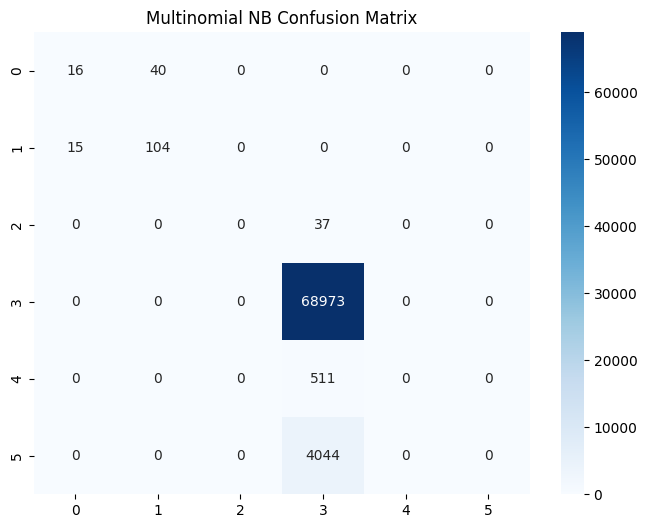

In [20]:
# Confusion Matrix
cm_mnb = confusion_matrix(y_test, y_pred_mnb)
cm_mnb = pd.DataFrame(cm_mnb, index=label_encoder.classes_, columns=label_encoder.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mnb, annot=True, fmt="d", cmap="Blues")
plt.title("Multinomial NB Confusion Matrix")
plt.show()


Gaussian NB Accuracy: 0.3901


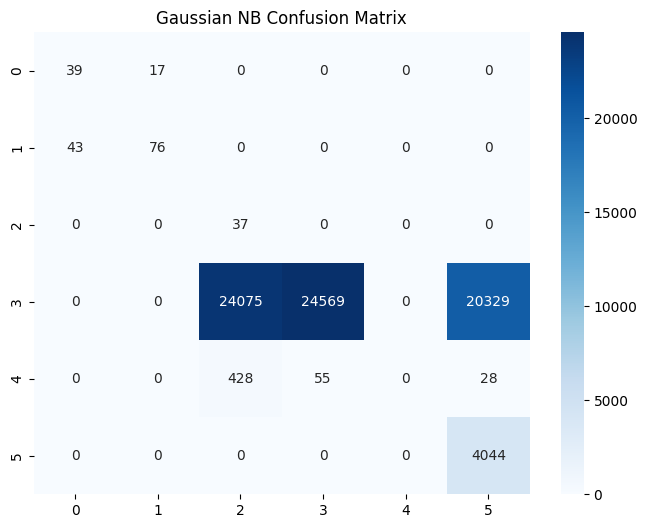

In [21]:
# Initialize and train model
gaussian_nb = GaussianNB()
gaussian_nb.fit(X_train, y_train)

# Predictions
y_pred_gnb = gaussian_nb.predict(X_test)

# Accuracy
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"Gaussian NB Accuracy: {accuracy_gnb:.4f}")

# Confusion Matrix
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
cm_gnb = pd.DataFrame(cm_gnb, index=label_encoder.classes_, columns=label_encoder.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gnb, annot=True, fmt="d", cmap="Blues")
plt.title("Gaussian NB Confusion Matrix")
plt.show()

Bernoulli NB Accuracy: 0.9370


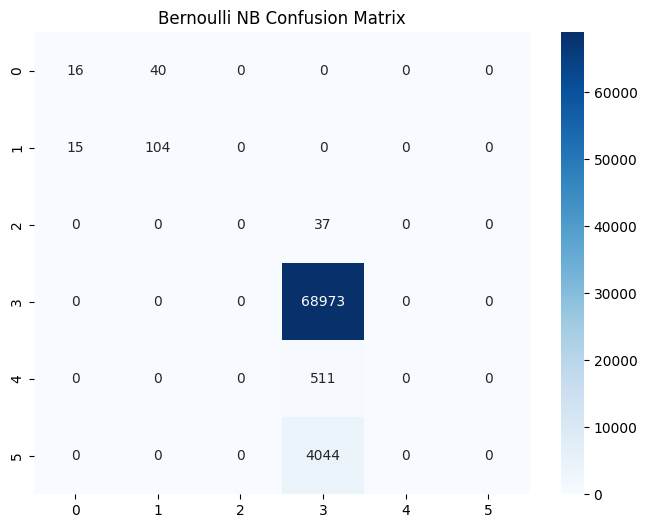

In [22]:
# Initialize and train model
bernoulli_nb = BernoulliNB()
bernoulli_nb.fit(X_train, y_train)

# Predictions
y_pred_bnb = bernoulli_nb.predict(X_test)

# Accuracy
accuracy_bnb = accuracy_score(y_test, y_pred_bnb)
print(f"Bernoulli NB Accuracy: {accuracy_bnb:.4f}")

# Confusion Matrix
cm_bnb = confusion_matrix(y_test, y_pred_bnb)
cm_bnb = pd.DataFrame(cm_bnb, index=label_encoder.classes_, columns=label_encoder.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bnb, annot=True, fmt="d", cmap="Blues")
plt.title("Bernoulli NB Confusion Matrix")
plt.show()


Multinomial Naïve Bayes Accuracy: 0.9370
Gaussian Naïve Bayes Accuracy: 0.3901
Bernoulli Naïve Bayes Accuracy: 0.9370


C:\Users\mihir\AppData\Local\Temp\ipykernel_29856\2104950623.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="coolwarm")


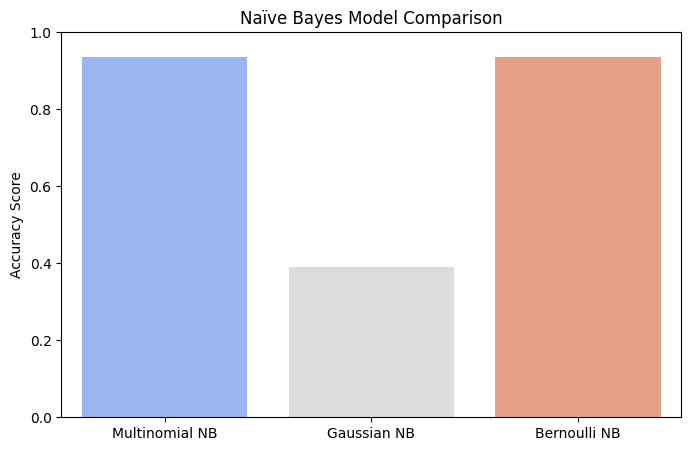

In [24]:
# Display Model Accuracies
print(f"Multinomial Naïve Bayes Accuracy: {accuracy_mnb:.4f}")
print(f"Gaussian Naïve Bayes Accuracy: {accuracy_gnb:.4f}")
print(f"Bernoulli Naïve Bayes Accuracy: {accuracy_bnb:.4f}")

# Visualizing the accuracies
plt.figure(figsize=(8, 5))
models = ["Multinomial NB", "Gaussian NB", "Bernoulli NB"]
accuracies = [accuracy_mnb, accuracy_gnb, accuracy_bnb]

sns.barplot(x=models, y=accuracies, palette="coolwarm")
plt.ylabel("Accuracy Score")
plt.title("Naïve Bayes Model Comparison")
plt.ylim(0, 1)
plt.show()


In [10]:
import pandas as pd

# Load dataset
df = pd.read_csv("cleaned_dataset.csv")
df.head()


C:\Users\mihir\AppData\Local\Temp\ipykernel_10792\3066347911.py:4: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_dataset.csv")


,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
0,2000001,1 Ceres,False,False,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,...,4.610000e-09,6.170000e-08,6.620000e-08,7.820000e-09,1.110000e-11,1.200000e-12,3.780000e-08,9.420000e-09,MBA,0.43301
1,2000002,2 Pallas,False,False,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,...,3.470000e-06,6.270000e-06,9.130000e-06,8.860000e-06,4.960000e-09,4.650000e-10,4.080000e-05,3.680000e-06,MBA,0.35936
2,2000003,3 Juno,False,False,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,...,3.220000e-06,1.660000e-05,1.770000e-05,8.110000e-06,4.360000e-09,4.410000e-10,3.530000e-05,3.110000e-06,MBA,0.33848
3,2000004,4 Vesta,False,False,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,...,2.170000e-07,3.880000e-07,1.790000e-07,1.210000e-06,1.650000e-09,2.610000e-10,4.100000e-06,1.270000e-06,MBA,0.39980
4,2000005,5 Astraea,False,False,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,...,2.740000e-06,2.890000e-05,2.980000e-05,8.300000e-06,4.730000e-09,5.520000e-10,3.470000e-05,3.490000e-06,MBA,0.52191


In [11]:
# Standardize string values
df["potentially_hazardous"] = df["potentially_hazardous"].astype(str).str.upper()
df["near_earth_object"] = df["near_earth_object"].astype(str).str.upper()

# Map to binary
df["potentially_hazardous"] = df["potentially_hazardous"].map({"TRUE": 1, "FALSE": 0, "N": 0}).astype(int)
df["near_earth_object"] = df["near_earth_object"].map({"TRUE": 1, "FALSE": 0, "UNKNOWN": 0}).astype(int)

df[["potentially_hazardous", "near_earth_object"]].head()


,potentially_hazardous,near_earth_object
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [12]:
# Keep columns needed for each NB flavor
columns_to_keep = [
    "potentially_hazardous", "absolute_magnitude", "diameter_km",
    "semi_major_axis_au", "orbital_inclination_deg", "near_earth_object",
    "aphelion_distance_au", "earth_moid_au", "orbit_fit_rms", "asteroid_class"
]
df = df[columns_to_keep].copy()


In [13]:
# Define feature sets
mnb_features = ["absolute_magnitude", "diameter_km", "semi_major_axis_au", "orbital_inclination_deg", "near_earth_object"]
gnb_features = ["absolute_magnitude", "diameter_km", "semi_major_axis_au", "aphelion_distance_au", "orbital_inclination_deg"]
cnb_features = ["earth_moid_au", "orbit_fit_rms", "asteroid_class"]
bnb_features = ["near_earth_object", "asteroid_class"]


In [14]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

def prep_with_smote(df, features):
    X = df[features]
    y = df["potentially_hazardous"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Apply SMOTE on training only
    sm = SMOTE(random_state=42)
    X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
    
    return X_train_sm, X_test, y_train_sm, y_test

X_train_mnb, X_test_mnb, y_train_mnb, y_test_mnb = prep_with_smote(df, mnb_features)
X_train_gnb, X_test_gnb, y_train_gnb, y_test_gnb = prep_with_smote(df, gnb_features)
X_train_cnb, X_test_cnb, y_train_cnb, y_test_cnb = prep_with_smote(df, cnb_features)
X_train_bnb, X_test_bnb, y_train_bnb, y_test_bnb = prep_with_smote(df, bnb_features)


ValueError: could not convert string to float: 'MBA'

In [6]:
from sklearn.naive_bayes import GaussianNB

# 🏋️ Train
gnb = GaussianNB()
gnb.fit(X_train_res, y_train_res)

# 📈 Predict
y_pred_gnb = gnb.predict(X_test)

# 🎯 Evaluate
acc_gnb = accuracy_score(y_test, y_pred_gnb)
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
print(f"Gaussian NB Accuracy: {acc_gnb:.4f}")


Gaussian NB Accuracy: 0.3902


In [7]:
from sklearn.naive_bayes import BernoulliNB

# 🏋️ Train
bnb = BernoulliNB()
bnb.fit(X_train_res, y_train_res)

# 📈 Predict
y_pred_bnb = bnb.predict(X_test)

# 🎯 Evaluate
acc_bnb = accuracy_score(y_test, y_pred_bnb)
cm_bnb = confusion_matrix(y_test, y_pred_bnb)
print(f"Bernoulli NB Accuracy: {acc_bnb:.4f}")


Bernoulli NB Accuracy: 0.2372


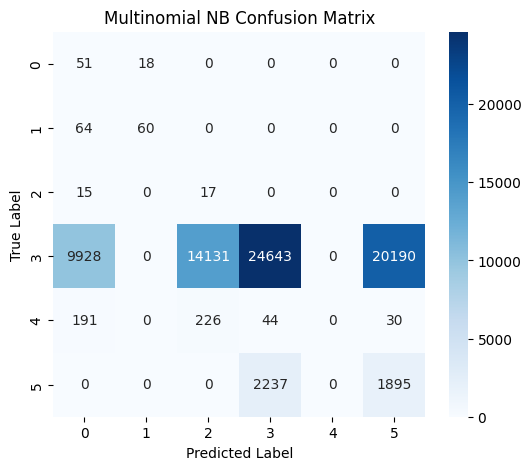

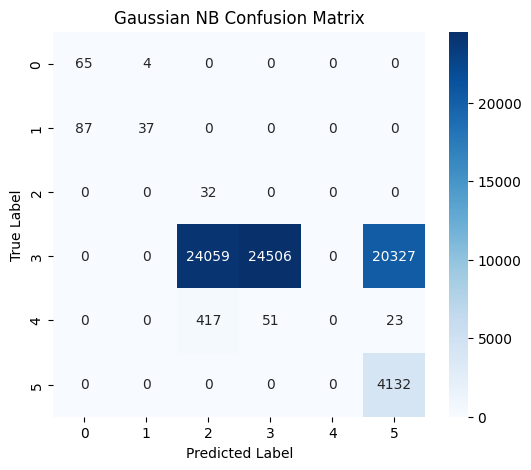

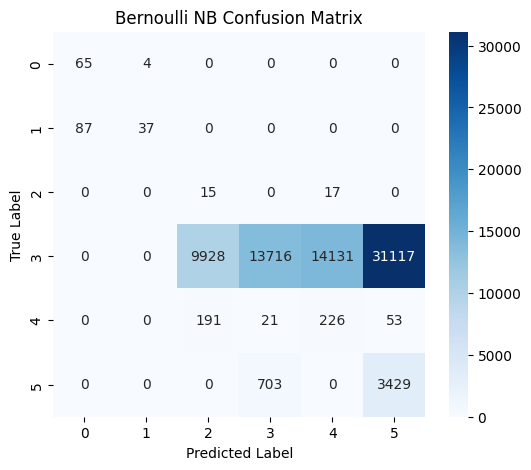

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_conf_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

plot_conf_matrix(cm_mnb, "Multinomial NB Confusion Matrix")
plot_conf_matrix(cm_gnb, "Gaussian NB Confusion Matrix")
plot_conf_matrix(cm_bnb, "Bernoulli NB Confusion Matrix")


C:\Users\mihir\AppData\Local\Temp\ipykernel_10792\545766530.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="mako")


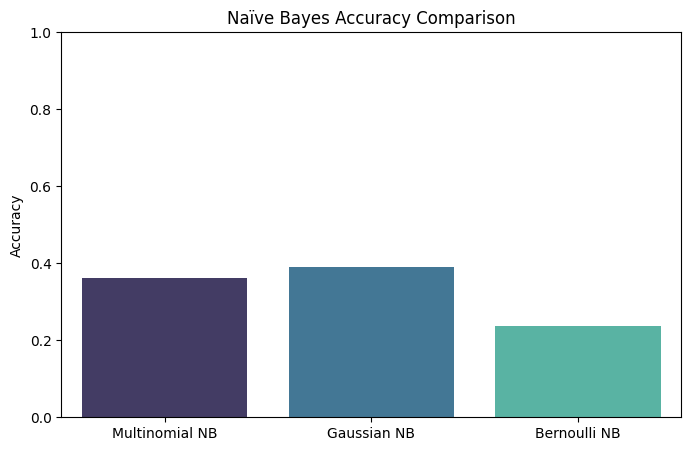

In [9]:
# 📊 Compare Accuracies
models = ["Multinomial NB", "Gaussian NB", "Bernoulli NB"]
accuracies = [acc_mnb, acc_gnb, acc_bnb]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette="mako")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Naïve Bayes Accuracy Comparison")
plt.show()
